# Experimento C — Outdoor vs. Indoor

## Preparación

In [4]:
%pip install pycolmap plotly open3d pandas tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Corrido en consola
# !sudo apt-get update -q
# !sudo apt-get install colmap -y -q

In [8]:
import os, shutil, time, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pycolmap
from pathlib import Path
from datetime import datetime

print("pycolmap:", pycolmap.__version__)


pycolmap: 4.0.4


### Paths e inicialización de carpetas

In [11]:
BASE_DIR    = Path('./expC')
LOGS_DIR    = BASE_DIR / 'logs'
RESULTS_DIR = BASE_DIR / 'results'
SPARSE_DIR  = BASE_DIR / 'sparse'
DB_DIR      = BASE_DIR / 'db'
DATA_DIR    = Path('./data')
EXP_D_DIR   = Path('./expD')

for d in [LOGS_DIR, RESULTS_DIR, SPARSE_DIR, DB_DIR, EXP_D_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SCENES     = ['garden', 'bonsai']
SCENE_TYPE = {'garden': 'outdoor', 'bicycle': 'outdoor',
              'bonsai': 'indoor',  'counter': 'indoor'}

CSV_PATH = RESULTS_DIR / 'results_expC.csv'

SCALE = 4

def get_image_path(scene):
    for scale in [f'images_{SCALE}', 'images']:
        p = DATA_DIR / scene / scale
        if p.exists():
            return p
    raise FileNotFoundError(f"No se encontró carpeta de imágenes para {scene}")


### Funciones varias

Para guardar los logs en un txt. Así se monitorea el avance sin ensuciar el cuaderno.

In [ ]:
def execute_to_file(cmd, log_path, stage_name):
    """Ejecuta un comando y guarda stdout/stderr en el log."""
    print(f"  [>] {stage_name}...", end='', flush=True)
    t0 = time.time()
    with open(log_path, 'a', encoding='utf-8') as f:
        f.write(f"\n{'='*20}\nCOMANDO: {cmd}\n{'='*20}\n")
        proc = subprocess.Popen(cmd, shell=True, stdout=f,
                                stderr=subprocess.STDOUT, text=True)
        proc.wait()
    dt = time.time() - t0
    status = f"OK ({dt:.1f}s)" if proc.returncode == 0 else f"ERROR (ver {log_path.name})"
    print(f" {status}")
    return proc.returncode, dt

Para guardar los resultados en un mismo csv

In [ ]:
def append_to_csv(metrics, csv_path):
    """Agrega o actualiza una fila en el CSV acumulativo."""
    df_new = pd.DataFrame([metrics])
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df = pd.concat([df, df_new], ignore_index=True)
        df = df.drop_duplicates(subset=['scene', 'config'], keep='last')
    else:
        df = df_new
    df.to_csv(csv_path, index=False)
    return df

Para contar componentes conexas

In [ ]:
def count_components(output_path):
    """Cuenta el número de componentes conexas generadas por COLMAP."""
    if not output_path.exists():
        return 0
    return len([d for d in output_path.iterdir()
                if d.is_dir() and d.name.isdigit()])

Para correr un pipeline COLMAP

Algunas definiciones y consideraciones

- `reco_path` es la ruta al componente conexo de mayor tamaño (el modelo principal) generado por el proceso de Sparse Reconstruction. COLMAP los enumera empezando por el 0 según la cantidad de imágenes registradas.
- objeto `reco`: carga a memoria RAM toda la información de un modelo 3D generado por COLMAP. Permite conectar las imágenes, cámaras y puntos 3D, calcular métricas de forma fácil usando sus métodos integrados, entre otros.
  - `reco.num_reg_images()`: cuenta cuantas imágenes tiene el modelo 3D. Sirve para evaluar cuantas de las imágenes que se le dieron al modelo fueron usadas.
  - `reco.compute_num_observations()`: calcula la suma de cuantas veces un punto 3D fue vistos por una imagen.
  - `reco.points3D`: los puntos que COLMAP logró reconstruir.
    - `reco.points3D.values()[x].track`: lista de todas las fotos donde aparece ese punto.

Como los archivos son pesados y el tiempo de ejecución es alto, se calcula la mayor cantidad de métricas posibles por ejecución, lo que no significa que se vayan a usar:
- scene, scene_type, config: contexto del epxerimento
- model: cámara usada
- total_images, images_registered, registration_ratio: registro de imágenes
- points_3d: cantidad de puntos reconstruidos
- mean_reprojection_error: promedio de error de ubicación de punto en la imagen y de ubicación caclulada.
- total_observations: cantidad de observaciones de todos los puntos en las imágenes
- obs_per_point: promedio de cámaras que ven a un mismo punto 3D
- avg_track_length: promedio de fotos en las que aparece cada punto
- std_track_length: dispersión de la visibilidad de los puntos
- median_track_length: mediana de de la visibilidad de los puntos
- max_track_length: el número máximo de fotos que comparten un mismo punto 3D
- num_connected_components: número de sub-modelos independientes generados
- execution_time_sec: tiempo de ejecución del proceso, en segundos
- sparse_path: ubicación de los archivos .bin o .txt resultantes
- images_path: ubicación de las fotos originales
- timestamp: fecha y hora de ejecución del pipeline


In [12]:
def run_experiment(scene, conf):
    """
    Ejecuta el pipeline COLMAP completo para una escena y configuración.
    Guarda métricas en el CSV acumulativo y retorna el dict de métricas.
    """
    img_path  = get_image_path(scene)
    db_path   = DB_DIR      / f"{scene}_{conf['name']}.db"
    out_path  = SPARSE_DIR  / scene / conf['name']
    log_path  = LOGS_DIR    / f"log_{scene}_{conf['name']}.txt"

    out_path.mkdir(parents=True, exist_ok=True)
    
    if db_path.exists():  
        db_path.unlink()
    if log_path.exists(): 
        log_path.unlink()

    # Contar imágenes
    imgs_total = len(list(img_path.glob('*.jpg')) +
                     list(img_path.glob('*.JPG')) +
                     list(img_path.glob('*.png')))

    print(f"\n>>> {scene} | {conf['name']}  ({imgs_total} imágenes)")

    t_start = time.time()

    extract_cmd = (
        f"colmap feature_extractor "
        f"--database_path {db_path} "
        f"--image_path {img_path} "
        f"--ImageReader.single_camera 1 "
        f"--ImageReader.camera_model {conf['model']} "
        f"--SiftExtraction.use_gpu 1 "
        f"{conf.get('ext', '')}"
    )
    match_cmd = (
        f"colmap exhaustive_matcher "
        f"--database_path {db_path} "
        f"--SiftMatching.use_gpu 1 "
        f"{conf.get('match', '')}"
    )
    map_cmd = (
        f"colmap mapper "
        f"--database_path {db_path} "
        f"--image_path {img_path} "
        f"--output_path {out_path} "
        f"{conf.get('map', '')}"
    )

    execute_to_file(extract_cmd, log_path, "Extracción de features")
    execute_to_file(match_cmd,   log_path, "Matching")
    execute_to_file(map_cmd,     log_path, "Mapping (SfM)")

    t_end = time.time()

    reco_path    = out_path / "0"
    n_components = count_components(out_path)

    if reco_path.exists():
        reco  = pycolmap.Reconstruction(str(reco_path))
        imgs_reg = reco.num_reg_images()
        pts3d    = reco.num_points3D()
        n_obs    = reco.compute_num_observations()
        tracks   = (np.array([p.track.length() for p in reco.points3D.values()])
                    if pts3d > 0 else np.array([0]))

        metrics = {
            'scene'                     : scene,
            'scene_type'                : SCENE_TYPE[scene],
            'config'                    : conf['name'],
            'model'                     : conf['model'],
            'total_images'              : imgs_total,
            'images_registered'         : imgs_reg,
            'registration_ratio'        : imgs_reg / imgs_total if imgs_total > 0 else 0,
            'points_3d'                 : pts3d,
            'mean_reprojection_error'   : reco.compute_mean_reprojection_error(),
            'total_observations'        : n_obs,
            'obs_per_point'             : n_obs / pts3d if pts3d > 0 else 0,
            'avg_track_length'          : float(np.mean(tracks)),
            'std_track_length'          : float(np.std(tracks)),
            'median_track_length'       : float(np.median(tracks)),
            'max_track_length'          : float(np.max(tracks)),
            'num_connected_components'  : n_components,
            'execution_time_sec'        : t_end - t_start,
            'sparse_path'               : str(reco_path),
            'images_path'               : str(img_path),
            'timestamp'                 : datetime.now().isoformat(),
        }
    else:
        print(f"  [!] Sin reconstrucción generada para {conf['name']} en {scene}")
        metrics = {
            'scene'                     : scene,
            'scene_type'                : SCENE_TYPE[scene],
            'config'                    : conf['name'],
            'model'                     : conf['model'],
            'total_images'              : imgs_total,
            'images_registered'         : 0,
            'registration_ratio'        : 0.0,
            'points_3d'                 : 0,
            'mean_reprojection_error'   : None,
            'total_observations'        : 0,
            'obs_per_point'             : 0.0,
            'avg_track_length'          : 0.0,
            'std_track_length'          : 0.0,
            'median_track_length'       : 0.0,
            'max_track_length'          : 0.0,
            'num_connected_components'  : n_components,
            'execution_time_sec'        : t_end - t_start,
            'sparse_path'               : None,
            'images_path'               : str(img_path),
            'timestamp'                 : datetime.now().isoformat(),
        }

    append_to_csv(metrics, CSV_PATH)
    print(f"  Tiempo total: {t_end - t_start:.1f}s | "
          f"Registradas: {metrics['images_registered']} | "
          f"Puntos 3D: {metrics['points_3d']}")
    return metrics


## Verificación de imágenes disponibles

In [13]:
images_count = {}
for scene in SCENES:
    ip = get_image_path(scene)
    imgs = (list(ip.glob('*.jpg')) + list(ip.glob('*.JPG')) +
            list(ip.glob('*.png')))
    images_count[scene] = len(imgs)
    print(f"{scene:10s}: {len(imgs):4d} imágenes  ({ip})")


garden    :  185 imágenes  (data/garden/images)
bonsai    :  292 imágenes  (data/bonsai/images_4)


## Configuraciones ejecutadas

`Cam_OpenCV` y `Ext_HighFeatures`

Estas dos configuraciones se eligieron por ser las más informativas para la comparación:

- **`Cam_OpenCV`**: modelo de cámara con distorsión radial/tangencial (baseline realista).  
- **`Ext_HighFeatures`**: extracción con 8 000 features — evalúa si más descriptores mejoran la reconstrucción. Inicialmente se intentó con 12 000 y 10 000 features, pero esto superaba las capacidades de la máquina.

Ambas corren sobre `garden` (outdoor) y `bonsai` (indoor).


In [16]:
CONFIGS_EXEC = [
    {
        "name"  : "Cam_OpenCV",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "",
        "map"   : "",
    },
    {
        "name"  : "Ext_HighFeatures",
        "model" : "OPENCV",
        "ext"   : "--SiftExtraction.max_num_features 8000",
        "match" : "",
        "map"   : "",
    },
]

results_exec = []
for scene in SCENES:
    for conf in CONFIGS_EXEC:
        if conf['name'] == "Cam_OpenCV":
            print(f"\n>>> Omitiendo {scene} con {conf['name']} (ya se corrió)")
            continue
        r = run_experiment(scene, conf)
        results_exec.append(r)

df_exec = pd.DataFrame(results_exec)
print("\n=== Resultados ejecutados ===")
# Algunas de las métricas
cols_show = ['scene', 'config', 'images_registered', 'registration_ratio',
             'points_3d', 'mean_reprojection_error', 'avg_track_length',
             'num_connected_components', 'execution_time_sec']
print(df_exec[cols_show].to_string(index=False))



>>> Omitiendo garden con Cam_OpenCV (ya se corrió)

>>> garden | Ext_HighFeatures  (185 imágenes)
  [>] Extracción de features... OK (74.1s)
  [>] Matching... OK (3159.8s)
  [>] Mapping (SfM)... OK (604.6s)
  Tiempo total: 3838.5s | Registradas: 185 | Puntos 3D: 142117

>>> Omitiendo bonsai con Cam_OpenCV (ya se corrió)

>>> bonsai | Ext_HighFeatures  (292 imágenes)
  [>] Extracción de features... OK (77.4s)
  [>] Matching... OK (1964.6s)
  [>] Mapping (SfM)... OK (1535.3s)
  Tiempo total: 3577.6s | Registradas: 292 | Puntos 3D: 99803

=== Resultados ejecutados ===
 scene           config  images_registered  registration_ratio  points_3d  mean_reprojection_error  avg_track_length  num_connected_components  execution_time_sec
garden Ext_HighFeatures                185                 1.0     142117                 1.241919          6.673600                         1         3838.544356
bonsai Ext_HighFeatures                292                 1.0      99803                 0.379539   

## Configuraciones previas

Las siguientes celdas contienen el código para otras configuraciones que se corrieron durante pruebas, que enriquecen el análisis, pero no sería provechoso correr de nuevo.

**No se ejecutan** por temas de tiempo


### Configuración 1

In [ ]:
CONFIGS_PREV_CAMMODELS = [
    {
        "name"  : "Cam_Pinhole",
        "model" : "PINHOLE",
        "ext"   : "",
        "match" : "",
        "map"   : "",
    },
]

# for scene in SCENES:
#     for conf in CONFIGS_PREV_CAMMODELS:
#         run_experiment(scene, conf)


### Configuración 2

In [ ]:
CONFIGS_PREV_EXT = [
    {
        "name"  : "Ext_LowFeatures",
        "model" : "OPENCV",
        "ext"   : "--SiftExtraction.max_num_features 4000",
        "match" : "",
        "map"   : "",
    },
]

# for scene in SCENES:
#     for conf in CONFIGS_PREV_EXT:
#         run_experiment(scene, conf)


### Configuración 3

In [ ]:
CONFIGS_PREV_MATCH = [
    {
        "name"  : "Match_Strict",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "--SiftMatching.max_error 1.5",
        "map"   : "",
    },
    {
        "name"  : "Match_Loose",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "--SiftMatching.max_error 6.0",
        "map"   : "",
    },
]

# for scene in SCENES:
#     for conf in CONFIGS_PREV_MATCH:
#         run_experiment(scene, conf)


### Configuración 4

In [ ]:
CONFIGS_PREV_MAP = [
    {
        "name"  : "Map_Robust",
        "model" : "OPENCV",
        "ext"   : "",
        "match" : "",
        "map"   : "--Mapper.min_model_size 10",
    },
]

# for scene in SCENES:
#     for conf in CONFIGS_PREV_MAP:
#         run_experiment(scene, conf)


# Resultados

## Resultados de configuraciones previas

In [17]:
import pandas as pd
from IPython.display import display, Markdown

In [26]:
csv_path = f"{RESULTS_DIR}/results_prev_config.csv"

df = pd.read_csv(csv_path)

display(Markdown("---"))
display(Markdown("### Escena **Bonsai**"))
df_bonsai = df[df['scene'] == 'bonsai']
display(df_bonsai)


---

### Escena **Bonsai**

,scene,block,config,model,images_registered,registration_ratio,points_3d,mean_reprojection_error,total_observations,obs_per_point,avg_track_length,execution_time_sec
0,bonsai,1_CameraModels,Cam_Pinhole,PINHOLE,292,1.0,72239,0.796043,622338,8.614986364706045,8.614986,3597.842511
1,bonsai,1_CameraModels,Cam_OpenCV,OPENCV,292,1.0,100055,0.379472,956584,9.560581680075959,9.560582,2441.979002
2,bonsai,2_SiftExtraction,Ext_LowFeatures,OPENCV,292,1.0,94397,0.381723,850643,9.011335105988538,9.011335,1961.334173
3,bonsai,3_SiftMatching,Match_Strict,OPENCV,292,1.0,97738,0.342238,949139,9.711054042439992,9.711054,2201.388714
4,bonsai,3_SiftMatching,Match_Loose,OPENCV,292,1.0,100362,0.387585,952932,9.494948287200335,9.494948,2712.299213
5,bonsai,4_Mapper,Map_Robust,OPENCV,292,1.0,99756,0.380247,955850,9.581879786679497,9.581880,2337.327977


In [27]:
display(Markdown("### Escena **Garden**"))
df_garden = df[df['scene'] == 'garden']
display(df_garden)

### Escena **Garden**

,scene,block,config,model,images_registered,registration_ratio,points_3d,mean_reprojection_error,total_observations,obs_per_point,avg_track_length,execution_time_sec
6,garden,1_CameraModels,Cam_Pinhole,PINHOLE,185,-,146174,1.235005,-,-,6.648576,4036.300242
7,garden,1_CameraModels,Cam_OpenCV,OPENCV,185,1.0,146102,1.235311,971808,6.651572189292412,6.651572,4814.585913
8,garden,2_SiftExtraction,Ext_LowFeatures,OPENCV,185,1.0,81707,1.324994,512722,6.275129425875384,6.275129,2053.690340
9,garden,3_SiftMatching,Match_Strict,OPENCV,185,1.0,130303,1.165194,907479,6.9643753405524045,6.964375,4468.464632
10,garden,3_SiftMatching,Match_Loose,OPENCV,185,1.0,148352,1.236523,976728,6.583854616048318,6.583855,4160.780422
11,garden,4_Mapper,Map_Robust,OPENCV,185,1.0,146002,1.235236,971617,6.6548197969890825,6.654820,4036.461030


## Resultados de configuraciones que se corrieron

In [29]:
csv_path = f"{RESULTS_DIR}/results_expC.csv"

df = pd.read_csv(csv_path)

display(Markdown("---"))
display(Markdown("### Escena **Bonsai**"))
df_bonsai = df[df['scene'] == 'bonsai']
display(df_bonsai)

display(Markdown("---"))
display(Markdown("### Escena **Garden**"))
df_garden = df[df['scene'] == 'garden']
display(df_garden)

---

### Escena **Bonsai**

,scene,scene_type,config,model,total_images,images_registered,registration_ratio,points_3d,mean_reprojection_error,total_observations,obs_per_point,avg_track_length,std_track_length,median_track_length,max_track_length,num_connected_components,execution_time_sec,sparse_path,images_path,timestamp
1,bonsai,indoor,Cam_OpenCV,OPENCV,292,292,1.0,100648,0.378105,958637,9.524650,9.524650,9.356960,6.0,133.0,1,2746.902072,expC/sparse/bonsai/Cam_OpenCV/0,data/bonsai/images_4,2026-05-12T19:35:13.771728
3,bonsai,indoor,Ext_HighFeatures,OPENCV,292,292,1.0,99803,0.379539,955508,9.573941,9.573941,9.382343,6.0,133.0,1,3577.596527,expC/sparse/bonsai/Ext_HighFeatures/0,data/bonsai/images_4,2026-05-12T21:49:37.833605


---

### Escena **Garden**

,scene,scene_type,config,model,total_images,images_registered,registration_ratio,points_3d,mean_reprojection_error,total_observations,obs_per_point,avg_track_length,std_track_length,median_track_length,max_track_length,num_connected_components,execution_time_sec,sparse_path,images_path,timestamp
0,garden,outdoor,Cam_OpenCV,OPENCV,185,185,1.0,146083,1.235615,971748,6.652027,6.652027,6.059012,4.0,113.0,1,4880.820108,expC/sparse/garden/Cam_OpenCV/0,data/garden/images,2026-05-12T18:41:56.862364
2,garden,outdoor,Ext_HighFeatures,OPENCV,185,185,1.0,142117,1.241919,948432,6.673600,6.673600,6.095007,4.0,114.0,1,3838.544356,expC/sparse/garden/Ext_HighFeatures/0,data/garden/images,2026-05-12T20:49:56.384660


# (a)

In [31]:
METRICS = {
    'config': 'Configuración', 
    'images_registered': 'Imgs registradas',
    'registration_ratio': 'Ratio registro',
    'points_3d': 'Puntos 3D',
    'mean_reprojection_error': 'Error reproyección (px)',
    'avg_track_length': 'Track length promedio',
    'num_connected_components': 'Componentes conexas',
    'execution_time_sec': 'Tiempo ejecución (s)',
}

path_expC = f"{RESULTS_DIR}/results_expC.csv"
path_prev = f"{RESULTS_DIR}/results_prev_config.csv"

df_expC = pd.read_csv(path_expC)
df_prev = pd.read_csv(path_prev)

df_all = pd.concat([df_prev, df_expC], ignore_index=True)

def mostrar_tabla_escena(df, nombre_escena):
    display(Markdown(f"---"))
    display(Markdown(f"### Escena **{nombre_escena.capitalize()}**"))
    
    filtro = df[df['scene'] == nombre_escena.lower()][list(METRICS.keys())]
    
    filtro = filtro.rename(columns=METRICS)
    
    display(filtro)

mostrar_tabla_escena(df_all, "bonsai")
mostrar_tabla_escena(df_all, "garden")

---

### Escena **Bonsai**

,Configuración,Imgs registradas,Ratio registro,Puntos 3D,Error reproyección (px),Track length promedio,Componentes conexas,Tiempo ejecución (s)
0,Cam_Pinhole,292,1.0,72239,0.796043,8.614986,NaN,3597.842511
1,Cam_OpenCV,292,1.0,100055,0.379472,9.560582,NaN,2441.979002
2,Ext_LowFeatures,292,1.0,94397,0.381723,9.011335,NaN,1961.334173
3,Match_Strict,292,1.0,97738,0.342238,9.711054,NaN,2201.388714
4,Match_Loose,292,1.0,100362,0.387585,9.494948,NaN,2712.299213
5,Map_Robust,292,1.0,99756,0.380247,9.581880,NaN,2337.327977
13,Cam_OpenCV,292,1.0,100648,0.378105,9.524650,1.0,2746.902072
15,Ext_HighFeatures,292,1.0,99803,0.379539,9.573941,1.0,3577.596527


---

### Escena **Garden**

,Configuración,Imgs registradas,Ratio registro,Puntos 3D,Error reproyección (px),Track length promedio,Componentes conexas,Tiempo ejecución (s)
6,Cam_Pinhole,185,-,146174,1.235005,6.648576,NaN,4036.300242
7,Cam_OpenCV,185,1.0,146102,1.235311,6.651572,NaN,4814.585913
8,Ext_LowFeatures,185,1.0,81707,1.324994,6.275129,NaN,2053.690340
9,Match_Strict,185,1.0,130303,1.165194,6.964375,NaN,4468.464632
10,Match_Loose,185,1.0,148352,1.236523,6.583855,NaN,4160.780422
11,Map_Robust,185,1.0,146002,1.235236,6.654820,NaN,4036.461030
12,Cam_OpenCV,185,1.0,146083,1.235615,6.652027,1.0,4880.820108
14,Ext_HighFeatures,185,1.0,142117,1.241919,6.673600,1.0,3838.544356


# (b)

In [32]:
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [33]:
import seaborn as sns

markers = {"bonsai": "s", "garden": "o"}

In [ ]:
df_plot = df_all[['scene', 'config', 'registration_ratio']].copy()print(df_all)

     scene             block            config    model  images_registered  \
0   bonsai    1_CameraModels       Cam_Pinhole  PINHOLE                292   
1   bonsai    1_CameraModels        Cam_OpenCV   OPENCV                292   
2   bonsai  2_SiftExtraction   Ext_LowFeatures   OPENCV                292   
3   bonsai    3_SiftMatching      Match_Strict   OPENCV                292   
4   bonsai    3_SiftMatching       Match_Loose   OPENCV                292   
5   bonsai          4_Mapper        Map_Robust   OPENCV                292   
6   garden    1_CameraModels       Cam_Pinhole  PINHOLE                185   
7   garden    1_CameraModels        Cam_OpenCV   OPENCV                185   
8   garden  2_SiftExtraction   Ext_LowFeatures   OPENCV                185   
9   garden    3_SiftMatching      Match_Strict   OPENCV                185   
10  garden    3_SiftMatching       Match_Loose   OPENCV                185   
11  garden          4_Mapper        Map_Robust   OPENCV         

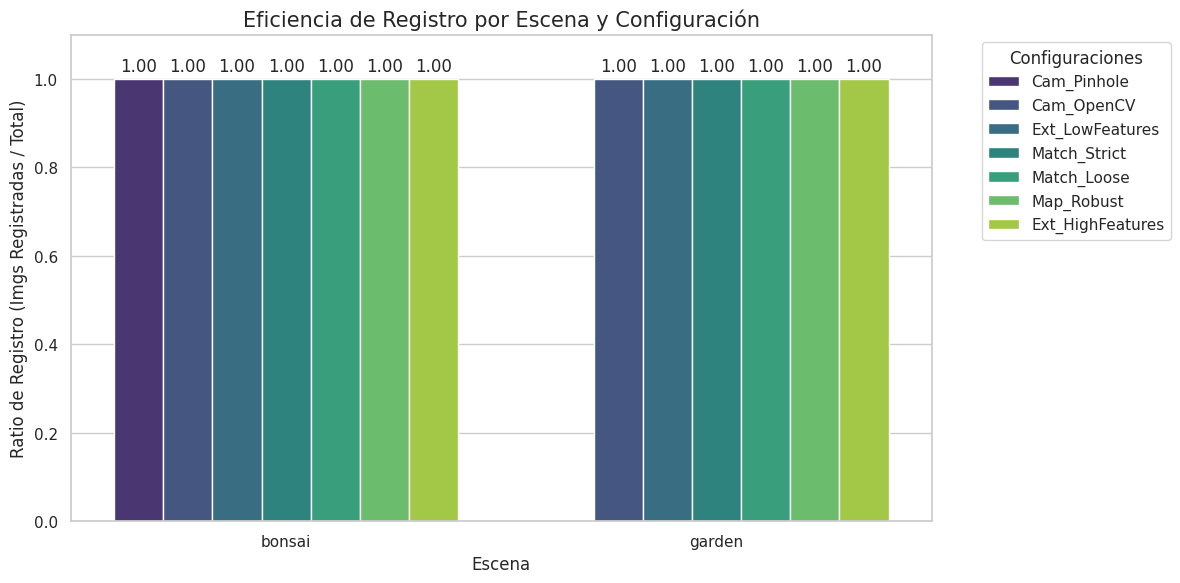

In [44]:
df_plot = df_all[['scene', 'config', 'registration_ratio']].copy()
df_plot['registration_ratio'] = pd.to_numeric(df_plot['registration_ratio'], errors='coerce')
df_plot = df_plot.dropna(subset=['registration_ratio'])

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

bar_plot = sns.barplot(
    data=df_plot, 
    x='scene', 
    y='registration_ratio', 
    hue='config', 
    palette='viridis'
)

plt.title('Eficiencia de Registro por Escena y Configuración', fontsize=15)
plt.xlabel('Escena', fontsize=12)
plt.ylabel('Ratio de Registro (Imgs Registradas / Total)', fontsize=12)
plt.ylim(0, 1.1)  

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.2f', padding=3)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Configuraciones')

plt.tight_layout()
plt.show()

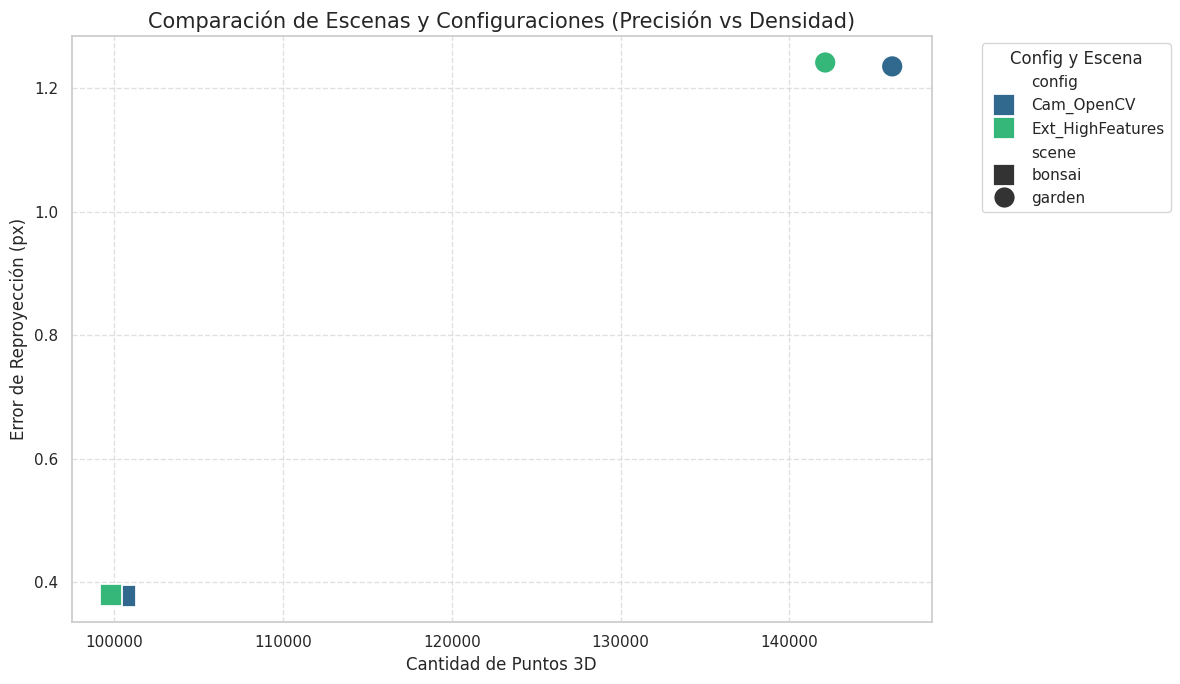

### 📋 Datos Detallados de la Comparación

,scene,config,points_3d,mean_reprojection_error,avg_track_length,execution_time_sec,timestamp
1,bonsai,Cam_OpenCV,100055,0.379472,9.560582,2441.979002,NaN
13,bonsai,Cam_OpenCV,100648,0.378105,9.524650,2746.902072,2026-05-12T19:35:13.771728
15,bonsai,Ext_HighFeatures,99803,0.379539,9.573941,3577.596527,2026-05-12T21:49:37.833605
7,garden,Cam_OpenCV,146102,1.235311,6.651572,4814.585913,NaN
12,garden,Cam_OpenCV,146083,1.235615,6.652027,4880.820108,2026-05-12T18:41:56.862364
14,garden,Ext_HighFeatures,142117,1.241919,6.673600,3838.544356,2026-05-12T20:49:56.384660


In [47]:

# 1. Preparar datos para el gráfico (solo las configs seleccionadas)
configs_to_show = ["Cam_OpenCV", "Ext_HighFeatures"]
markers = {"bonsai": "s", "garden": "o"}

# Filtramos y limpiamos de forma segura
df_viz = df_all[df_all['config'].isin(configs_to_show)].copy()
df_viz['points_3d'] = pd.to_numeric(df_viz['points_3d'], errors='coerce')
df_viz['mean_reprojection_error'] = pd.to_numeric(df_viz['mean_reprojection_error'], errors='coerce')
df_viz = df_viz.dropna(subset=['points_3d', 'mean_reprojection_error'])

# 2. Crear el gráfico combinado
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=df_viz,
    x='points_3d',
    y='mean_reprojection_error',
    hue='config',    # Color por Configuración
    style='scene',   # Forma por Escena
    markers=markers,
    s=250,
    palette='viridis' # Paleta profesional
)

plt.title('Comparación de Escenas y Configuraciones (Precisión vs Densidad)', fontsize=15)
plt.xlabel('Cantidad de Puntos 3D', fontsize=12)
plt.ylabel('Error de Reproyección (px)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Config y Escena')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Mostrar la tabla con los datos específicos y Timestamp
display(Markdown("### 📋 Datos Detallados de la Comparación"))

# Seleccionamos las columnas de interés incluyendo el timestamp
cols_interes = [
    'scene', 'config', 'points_3d', 'mean_reprojection_error', 
    'avg_track_length', 'execution_time_sec', 'timestamp'
]

# Mostramos la tabla formateada
display(df_viz[cols_interes].sort_values(['scene', 'config']))

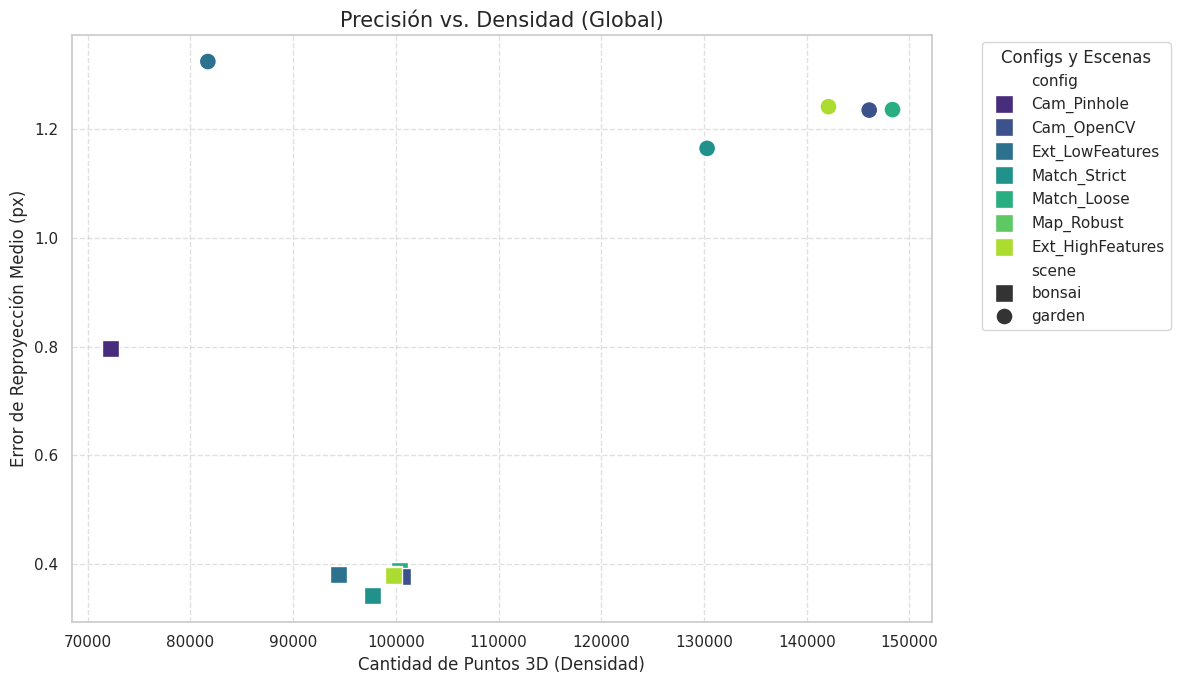

In [48]:

df_clean_all = df_all.copy()

# 2. Convertir ejes a numérico (esto maneja guiones '-' o strings inesperados)
df_clean_all['points_3d'] = pd.to_numeric(df_clean_all['points_3d'], errors='coerce')
df_clean_all['mean_reprojection_error'] = pd.to_numeric(df_clean_all['mean_reprojection_error'], errors='coerce')

# 3. Eliminar filas donde falte alguno de los dos datos principales del gráfico
df_clean_all = df_clean_all.dropna(subset=['points_3d', 'mean_reprojection_error'])

# 4. Graficar
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=df_clean_all, 
    x='points_3d', 
    y='mean_reprojection_error', 
    hue='config', 
    style='scene', 
    markers=markers, # Asegúrate que markers = {"bonsai": "s", "garden": "o"} esté definido
    s=150, 
    palette='viridis'
)

plt.title('Precisión vs. Densidad (Global)', fontsize=15)
plt.xlabel('Cantidad de Puntos 3D (Densidad)', fontsize=12)
plt.ylabel('Error de Reproyección Medio (px)', fontsize=12)

# Mejorar la leyenda para que no tape los puntos
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Configs y Escenas')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

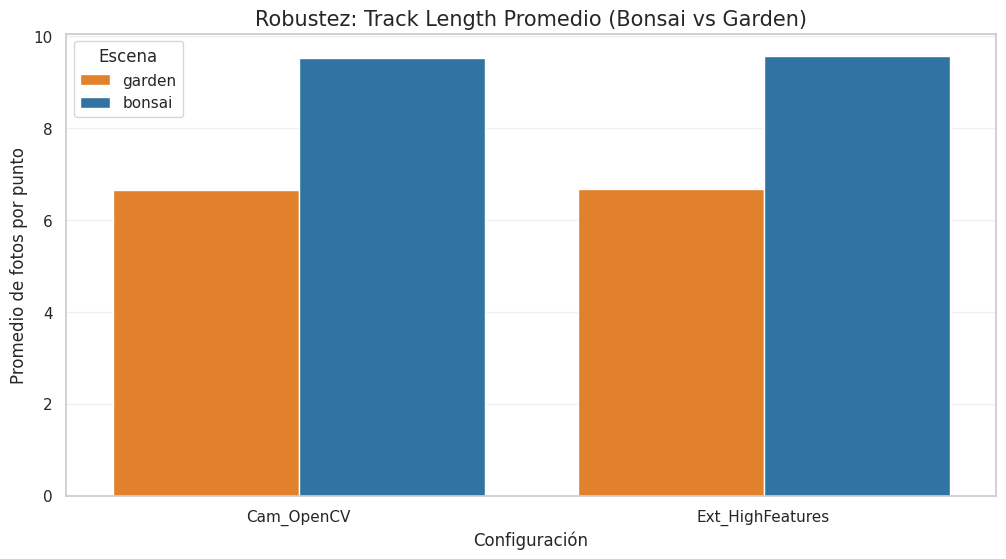

In [49]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_expC,
    x='config',
    y='avg_track_length',
    hue='scene',
    palette={'bonsai': '#1f77b4', 'garden': '#ff7f0e'}
)

plt.title('Robustez: Track Length Promedio (Bonsai vs Garden)', fontsize=15)
plt.ylabel('Promedio de fotos por punto')
plt.xlabel('Configuración')
plt.legend(title='Escena')
plt.grid(axis='y', alpha=0.3)

plt.show()

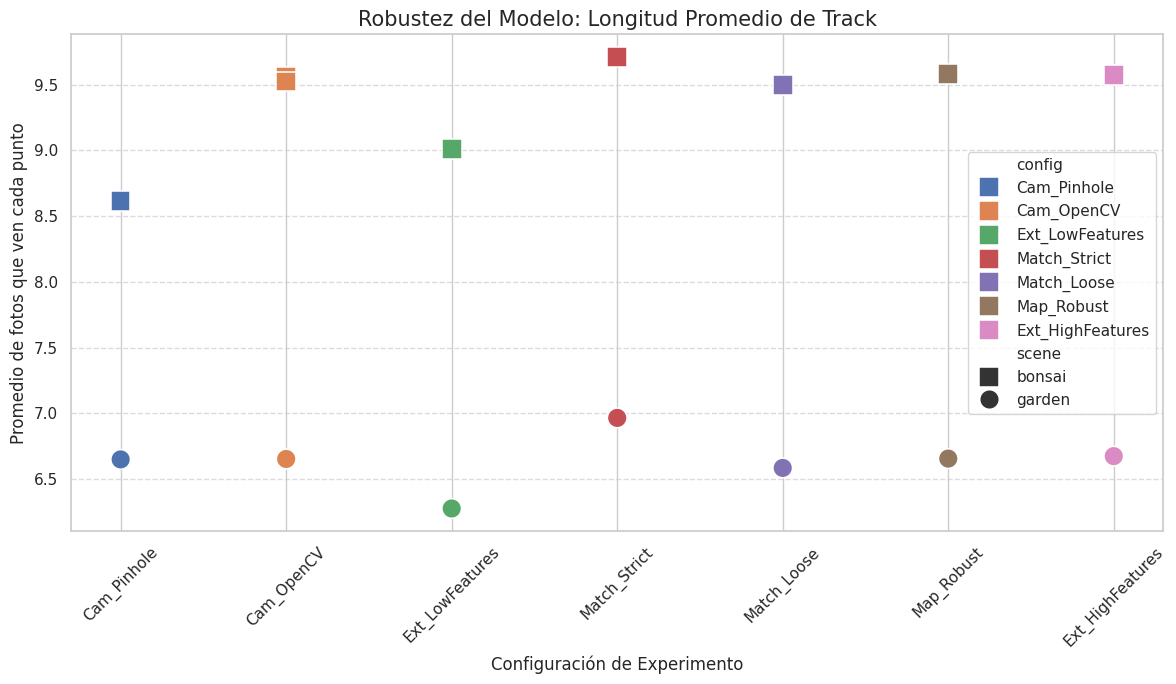

In [50]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_all, 
    x='config', 
    y='avg_track_length', 
    hue='config', 
    style='scene', 
    markers=markers,
    s=200,
    legend=True
)

plt.title('Robustez del Modelo: Longitud Promedio de Track', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Promedio de fotos que ven cada punto', fontsize=12)
plt.xlabel('Configuración de Experimento', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

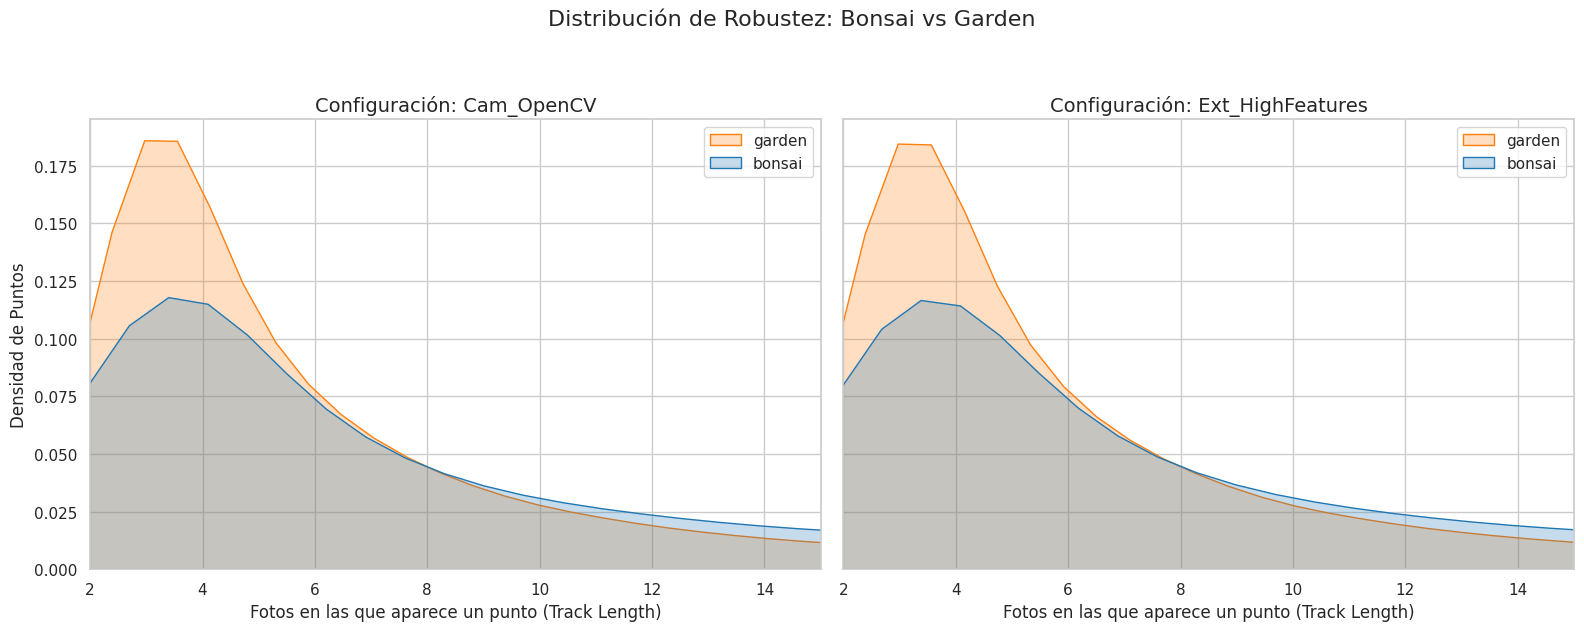

In [53]:

# Configuraciones a comparar
configs_to_show = ["Cam_OpenCV", "Ext_HighFeatures"]
palette = {'bonsai': '#1f77b4', 'garden': '#ff7f0e'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, cfg_name in enumerate(configs_to_show):
    # Filtrar el dataframe por la configuración actual
    df_cfg = df_expC[df_expC['config'] == cfg_name]
    
    for _, row in df_cfg.iterrows():
        path = row['sparse_path']
        if path and pycolmap.Reconstruction(path):
            reco = pycolmap.Reconstruction(path)
            # Obtenemos la longitud de los tracks para cada punto 3D
            lengths = [p.track.length() for p in reco.points3D.values()]
            
            # Graficar la distribución
            sns.kdeplot(
                lengths, 
                ax=axes[i], 
                label=row['scene'], 
                fill=True, 
                color=palette.get(row['scene']),
                bw_adjust=1.5
            )

    axes[i].set_title(f'Configuración: {cfg_name}', fontsize=14)
    axes[i].set_xlabel('Fotos en las que aparece un punto (Track Length)')
    axes[i].set_xlim(2, 15) # Zoom en el área de mayor interés
    axes[i].legend()

axes[0].set_ylabel('Densidad de Puntos')
plt.suptitle('Distribución de Robustez: Bonsai vs Garden', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# (c)

# Exportar datos para Experimento D

In [51]:
# Guardar paths de reconstrucciones y métricas base en ./expD/
exp_d_recs = df_all[['scene', 'config', 'model',
                      'sparse_path', 'images_path',
                      'images_registered', 'registration_ratio',
                      'points_3d', 'mean_reprojection_error',
                      'avg_track_length', 'execution_time_sec']].copy()

out_path_d = EXP_D_DIR / 'reconstructions_for_D.csv'
exp_d_recs.to_csv(out_path_d, index=False)
print(f"Guardado para D: {out_path_d}")
print(exp_d_recs[['scene','config','sparse_path']].to_string(index=False))


Guardado para D: expD/reconstructions_for_D.csv
 scene           config                           sparse_path
bonsai      Cam_Pinhole                                   NaN
bonsai       Cam_OpenCV                                   NaN
bonsai  Ext_LowFeatures                                   NaN
bonsai     Match_Strict                                   NaN
bonsai      Match_Loose                                   NaN
bonsai       Map_Robust                                   NaN
garden      Cam_Pinhole                                   NaN
garden       Cam_OpenCV                                   NaN
garden  Ext_LowFeatures                                   NaN
garden     Match_Strict                                   NaN
garden      Match_Loose                                   NaN
garden       Map_Robust                                   NaN
garden       Cam_OpenCV       expC/sparse/garden/Cam_OpenCV/0
bonsai       Cam_OpenCV       expC/sparse/bonsai/Cam_OpenCV/0
garden Ext_HighFeature